
Processing road...


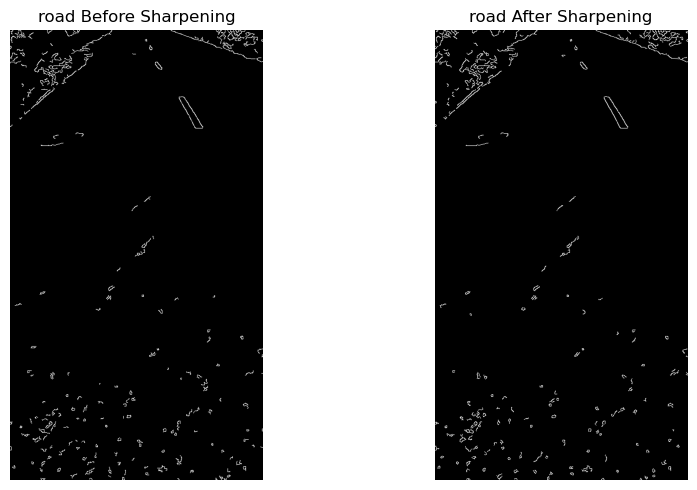

road: Processed median_contrast frame 1
road: Processed median_hist_eq frame 1


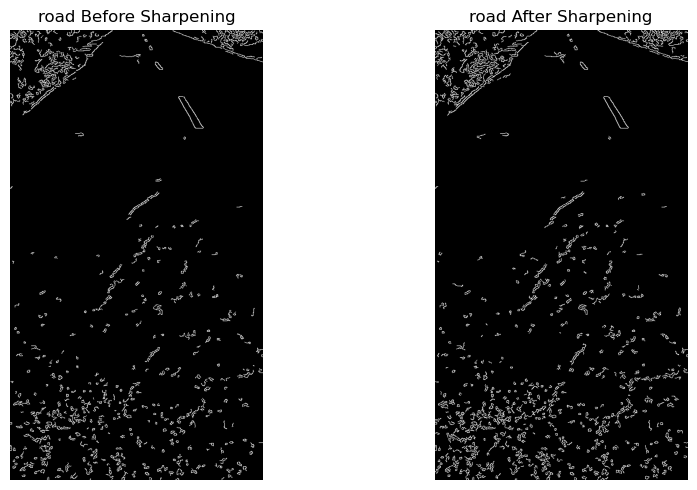

road: Processed gaussian_contrast frame 1
road: Processed gaussian_hist_eq frame 1
road: Processed median_contrast frame 2
road: Processed median_hist_eq frame 2
road: Processed gaussian_contrast frame 2
road: Processed gaussian_hist_eq frame 2
road: Processed median_contrast frame 3
road: Processed median_hist_eq frame 3
road: Processed gaussian_contrast frame 3
road: Processed gaussian_hist_eq frame 3
road: Processed median_contrast frame 4
road: Processed median_hist_eq frame 4
road: Processed gaussian_contrast frame 4
road: Processed gaussian_hist_eq frame 4
road: Processed median_contrast frame 5
road: Processed median_hist_eq frame 5
road: Processed gaussian_contrast frame 5
road: Processed gaussian_hist_eq frame 5
road: Processed median_contrast frame 6
road: Processed median_hist_eq frame 6
road: Processed gaussian_contrast frame 6
road: Processed gaussian_hist_eq frame 6
road: Processed median_contrast frame 7
road: Processed median_hist_eq frame 7
road: Processed gaussian_con

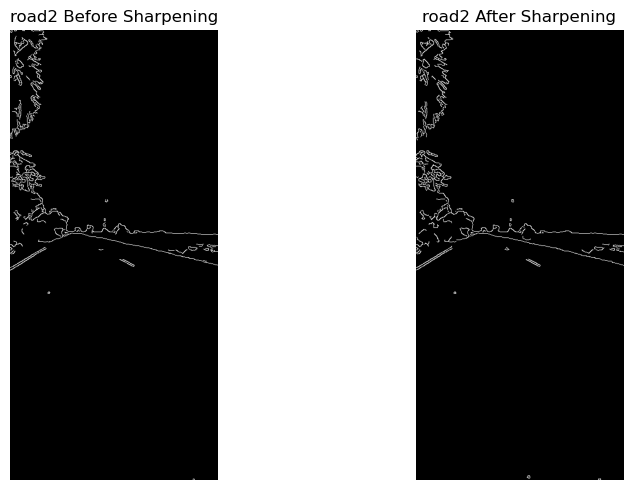

road2: Processed median_contrast frame 1
road2: Processed median_hist_eq frame 1


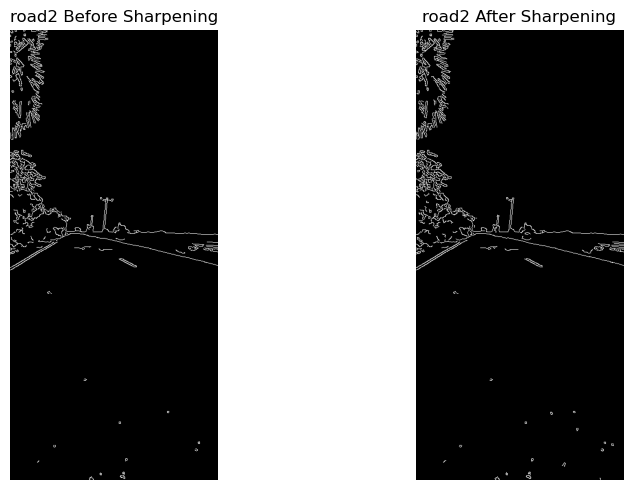

road2: Processed gaussian_contrast frame 1
road2: Processed gaussian_hist_eq frame 1
road2: Processed median_contrast frame 2
road2: Processed median_hist_eq frame 2
road2: Processed gaussian_contrast frame 2
road2: Processed gaussian_hist_eq frame 2
road2: Processed median_contrast frame 3
road2: Processed median_hist_eq frame 3
road2: Processed gaussian_contrast frame 3
road2: Processed gaussian_hist_eq frame 3
road2: Processed median_contrast frame 4
road2: Processed median_hist_eq frame 4
road2: Processed gaussian_contrast frame 4
road2: Processed gaussian_hist_eq frame 4
road2: Processed median_contrast frame 5
road2: Processed median_hist_eq frame 5
road2: Processed gaussian_contrast frame 5
road2: Processed gaussian_hist_eq frame 5
road2: Processed median_contrast frame 6
road2: Processed median_hist_eq frame 6
road2: Processed gaussian_contrast frame 6
road2: Processed gaussian_hist_eq frame 6
road2: Processed median_contrast frame 7
road2: Processed median_hist_eq frame 7
road

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

num_frames = 30
display_frame = 1   # show only one frame in notebook
videos = ["road", "road2"]   # video names

def sharpen_image(img):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)

def sharpness_metric(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

def edge_image(img):
    return cv2.Canny(img, 100, 200)

for video in videos:

    print(f"\nProcessing {video}...")

    # -------- INPUT FOLDERS FROM MEMBER 2 --------
    input_folders = {
        "median_contrast": f"{video}_member2_median_contrast",
        "median_hist_eq": f"{video}_member2_median_hist_eq",
        "gaussian_contrast": f"{video}_member2_gaussian_contrast",
        "gaussian_hist_eq": f"{video}_member2_gaussian_hist_eq"
    }

    # -------- OUTPUT FOLDERS --------
    output_folders = {
        "sharpened": f"{video}_member3_sharpened",
        "edges": f"{video}_member3_edges",
        "median_comparisons": f"{video}_member3_median_edge_comparisons",
        "gaussian_comparisons": f"{video}_member3_gaussian_edge_comparisons"
    }

    # Create folders
    for folder in output_folders.values():
        os.makedirs(folder, exist_ok=True)

    metrics = []
    shown_median = False
    shown_gaussian = False

    for idx in range(1, num_frames + 1):

        for method in input_folders:

            input_path = f"{input_folders[method]}/frame_{idx}.jpg"
            img = cv2.imread(input_path, 0)

            if img is None:
                print(f"{video} {method} frame {idx} not found")
                continue

            # Optional smoothing
            smoothed = cv2.GaussianBlur(img, (5, 5), 0)

            # Sharpen
            sharpened = sharpen_image(smoothed)

            # Save sharpened image
            cv2.imwrite(
                f"{output_folders['sharpened']}/{method}_frame_{idx}.jpg",
                sharpened
            )

            # Edge detection
            edges_input = edge_image(img)
            edges_sharp = edge_image(sharpened)

            cv2.imwrite(
                f"{output_folders['edges']}/{method}_edges_{idx}.jpg",
                edges_sharp
            )

            # Select comparison folder
            if "median" in method:
                comparison_folder = output_folders["median_comparisons"]
            else:
                comparison_folder = output_folders["gaussian_comparisons"]

            # -------- EDGE COMPARISON --------
            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(edges_input, cmap='gray')
            plt.title(f"{video} Before Sharpening")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(edges_sharp, cmap='gray')
            plt.title(f"{video} After Sharpening")
            plt.axis('off')

            plt.tight_layout()
            plt.savefig(f"{comparison_folder}/{method}_compare_{idx}.jpg")

            # Show only one median and one gaussian example for each video
            if idx == display_frame:
                if "median" in method and not shown_median:
                    plt.show()
                    shown_median = True
                elif "gaussian" in method and not shown_gaussian:
                    plt.show()
                    shown_gaussian = True
                else:
                    plt.close()
            else:
                plt.close()

            # Store metrics
            metrics.append({
                "Frame": idx,
                "Method": method,
                "Sharpness_Before": sharpness_metric(img),
                "Sharpness_After": sharpness_metric(sharpened)
            })

            print(f"{video}: Processed {method} frame {idx}")

    # Save metrics CSV for each video
    csv_name = f"{video}_member3_metrics.csv"
    with open(csv_name, "w") as f:
        f.write("Frame,Method,Sharpness_Before,Sharpness_After\n")
        for m in metrics:
            f.write(f"{m['Frame']},{m['Method']},{m['Sharpness_Before']},{m['Sharpness_After']}\n")

    print(f"{video} processing complete. Metrics saved in {csv_name}")

print("\nMember 3 processing complete for all videos.")